# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Dataset `users`**
- `city`: 469 nulos (11.72%). Se recomienda imputar con la media o moda, o dejar como N/A.
- `churn_date`: 3534 nulos (88.35%). Aunque el porcentaje es alto, los nulos podrían indicar los usuarios no han abandonado. Se recomienda conservar como indicador de usuarios activos 

**Dataset `usage`**
- `date`: 50 nulos (0.12%). Se pueden eliminar las filas o mantener en el análisis y no tendrían mayor impacto.
- `duration`: 22076 nulos (55.19%). Los nulos corresponden a registros de tipo `text`. Se recomienda conservarlos y no imputar.
- `length`: 17896 nulos (44.74%). Los nulos corresponden a registros de tipo `call`. Se recomienda conservarlos y no imputar.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene valores entre 10000 y 13999. En este caso se trata como una variable numérica pero las estadísticas descriptivas carecen de valor ya que se trata de una variable identificadora. 
- La columna `age` tiene un valor mínimo de -999, que no corresponde a una edad válida. Es probable que este valor se haya utilizado para representar campos faltantes y está teniendo un efecto sobre las medidas de tendencia central y dispersión de la variable. Se recomienda reemplazar estas variables por nulos.


In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`corresponden a identificadores de registros y usuarios respectivamente. En estos casos se tratan como una variables numéricas pero las estadísticas descriptivas carecen de valor ya que se trata de variables identificadoras.
- La columna `duration` tiene una media de 5.20 y una mediana de 3.50. El valor máximo (120) por lo que se recomienda revisar la distribución de la variable e identificar posibles outliers para decidir como manejarlos.
- La columna `length` tiene una media de 52.13 y una mediana de 50.00. El valor máximo (1490) sugiere la existencia de outliers, por lo que se deben revisar estos valores para decidir como manejarlos.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [15]:
users[columnas_user].isna().sum()

city    469
plan      0
dtype: int64

- La columna `city` tiene 7 categorías diferentes, Bogotá es la más frecuente con 808 registros. Presenta 469 nulos.
- La columna `plan` tiene 2 categorías diferentes, Básico es la más frecuente con 2595 registros. No presenta nulos.

In [16]:
# explorar columna categórica de usage
usage[['type']].describe()

,type
count,40000
unique,2
top,text
freq,22092


In [17]:
usage[['type']].isna().sum()

type    0
dtype: int64

- La columna `type` tiene dos categorias diferentes, text es la más frecuente con 22092 registros. No presenta nulos.


---
**Valores inválidos o sentinels**  
 - En la columna `age` del dataset `users` se encontró el valor -999, que corresponde a una edad inválida que probablemente se utiliza como sentinel para representar valores faltantes. Se recomienda verificar la proporción de estos datos en la columna para decidir si reemplazarlos por `NaN` o imputarlos con la media.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dtype)

datetime64[ns]


In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dtype)

datetime64[ns]


In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` los registros corresponden a los años 2022, 2023, 2024 y 2026. No existen registros para 2025 y 2026 presenta únicamente 40 registros.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros con fecha válida corresponden al año 2024, con un total de 39950 registros.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- En `reg_date` se encontraron 40 registros correspondientes al año 2026, posteriores al periodo de análisis de `usage` (2024). Estas fechas deben considerarse fuera del rango esperado y se recomienda verificar su origen antes de utilizarlas.
- En `date`, todos los registros con fecha válida corresponden a 2024, por lo que no se identifican fechas fuera del rango esperado.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
(users['city'] == '?').sum()

0

In [24]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(
    users['reg_date'].dt.year != 2026, pd.NA
)

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

- Los valores nulos de `duration` y `length` presentan un patrón Missing at Random (MAR), ya que su ausencia depende de la variable `type`. `duration` presenta valores casi exclusivamente cuanto `type` es `text`, mientras que `length` presenta valores nulos casi exclusivamente cuando `type` es `call`.
- Se recomienda conservar estos valores como nulos y no imputarlos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "duration": "sum",
    "length": "sum",
    "is_text": "sum",
    "is_call": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,duration,length,is_text,is_call
0,10000,23.70,258.0,7,3
1,10001,33.18,226.0,5,10
2,10002,10.74,225.0,5,2


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "length": "longitud_mensaje",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_minutos_llamada,longitud_mensaje,cant_mensajes,cant_llamadas
0,10000,23.70,258.0,7,3
1,10001,33.18,226.0,5,10
2,10002,10.74,225.0,5,2


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,longitud_mensaje,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,23.70,258.0,7.0,3.0
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,33.18,226.0,5.0,10.0
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,10.74,225.0,5.0,2.0
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,8.99,530.0,11.0,3.0
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,8.01,229.0,4.0,3.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'longitud_mensaje', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,longitud_mensaje,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,288.128032,23.317054
std,17.689919,2.358416,2.144238,180.906841,18.168095
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,184.000000,11.120000
50%,48.000000,5.000000,4.000000,268.000000,19.780000
75%,63.000000,7.000000,6.000000,361.000000,31.415000
max,79.000000,17.000000,15.000000,2028.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

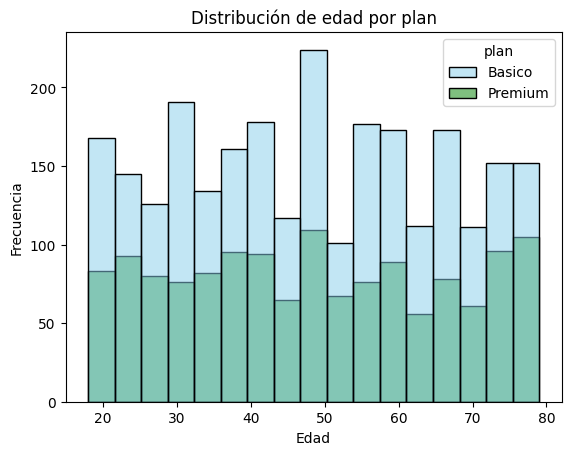

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue","green"])
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribucipon de edades es similar entre los planes Básico y Premium, sin observarse una concentración clara de un plan en un rango de edad específico. El plan básico tiene mayor frecuencia de usuarios en la mayoría de rangos de edad.

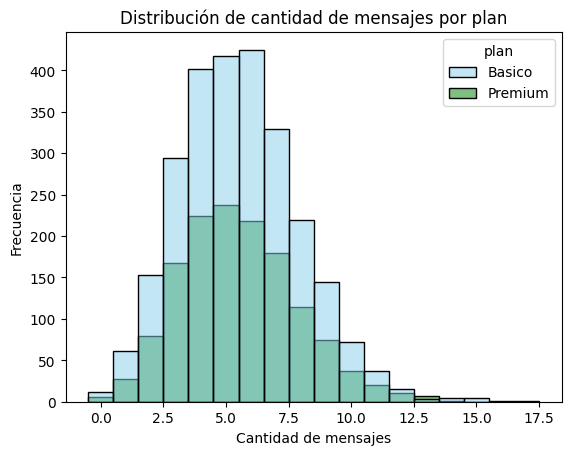

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", discrete=True, palette=["skyblue","green"])
plt.title("Distribución de cantidad de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La cantidad de mensajes presenta una distribución similar en ambos planes, concentrandose principalmente entre 3 y 8 mensajes.
- El plan Básico presenta frecuencias más altas que el plan Premium, aunque podría estar relacionado con un mayor número de usuarios que tienen plan Básico. No existe una diferencia en el patrón de distribución de los dos planes.

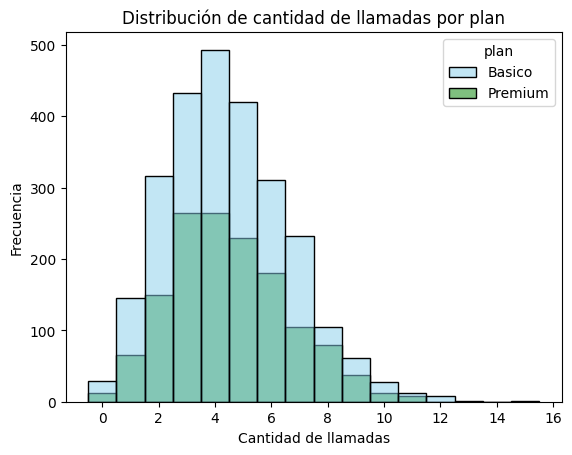

In [34]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", discrete=True, palette=["skyblue","green"])
plt.title("Distribución de cantidad de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- La cantidad de llamadas presenta una distribución similar en ambos planes, concentrandose principalmente entre 2 y 7 llamadas.
- La distribución presenta un ligero sesgo hacía la derecha, con algunos usuarios que realizan más de 10 llamadas. 

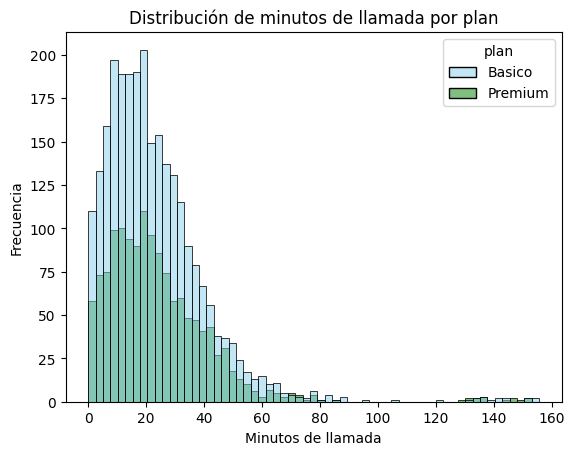

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue","green"])
plt.title("Distribución de minutos de llamada por plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de los minutos de llamada presenta un sesgo hacia la derecha en ambos planes.
- La mayoría de los usuarios realiza entre 5 y 20 minutos, y algunos usuarios registran tiempos mucho mayores. Las distribuciones de los dos planes muestran un patrón similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

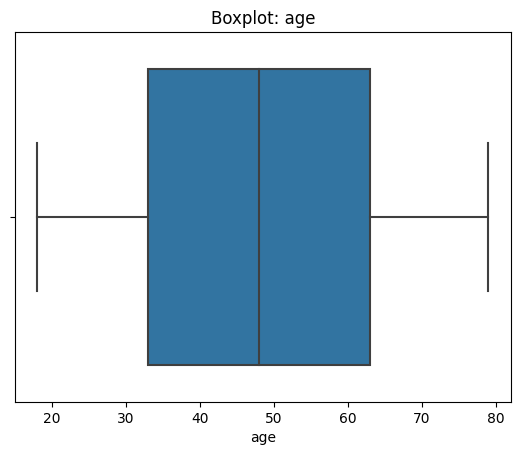

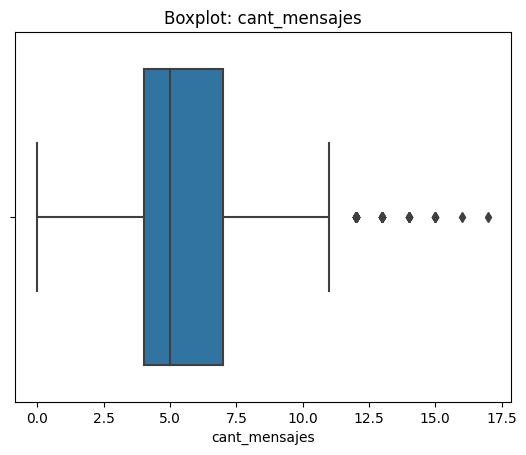

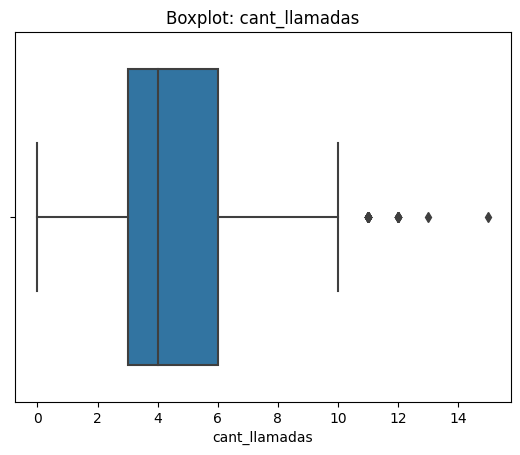

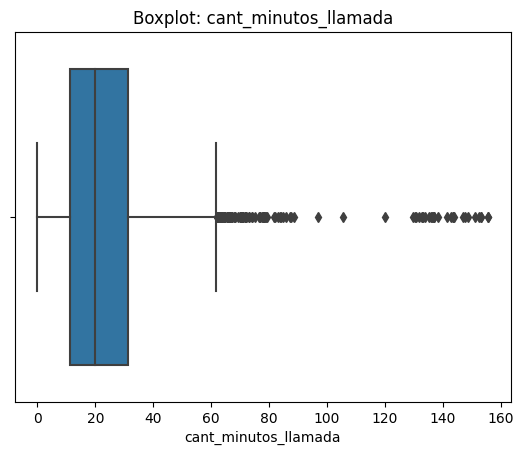

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers, todos los registros de edad se encuentran dentro de los límites del boxplot.
- cant_mensajes: presenta algunos outliers hacía el extremo superior, que corresponden a algunos usuarios con más de 12 mensajes.
- cant_llamadas: presenta algunos outliers hacía el extremo superior, que corresponen a algunos usuarios con más de 11 llamadas.
- cant_minutos_llamada: presenta una gran cantidad de outliers hacía el extremo superior, esto concuerda con la distribución observada en el histograma.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: límite inferior = {limite_inferior:.2f}")
    print(f"{col}: límite superior = {limite_superior:.2f}")

cant_mensajes: límite inferior = -0.50
cant_mensajes: límite superior = 11.50
cant_llamadas: límite inferior = -1.50
cant_llamadas: límite superior = 10.50
cant_minutos_llamada: límite inferior = -19.32
cant_minutos_llamada: límite superior = 61.86


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener los outliers. Porque el límite superior es 11.50 mensajes, y el máximo observado es 17. Aunque se presentan valores atípicos, estos representan cantidades plausibles de mensajes y no existe evidencia de que sean errores.
- cant_llamadas: mantener los outliers. Porque el límite superior es 10.5 llamadas, el máximo observado es 15 llamadas. Estos valores atípicos representan valores plausibles, y no parecen errores de registro.
- cant_minutos_llamada: mantener los outliers. El límite superior es 61.86 y el máximo registrado es 155.69 minutos de llamada. Aunque existen numerosos valores atípicos por encima del límite superior, estos son valores posibles de consumo y no representan errores de registro.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis = 1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,longitud_mensaje,cant_mensajes,cant_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,23.70,258.0,7.0,3.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,33.18,226.0,5.0,10.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,10.74,225.0,5.0,2.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,8.99,530.0,11.0,3.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,8.01,229.0,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,longitud_mensaje,cant_mensajes,cant_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,23.70,258.0,7.0,3.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,33.18,226.0,5.0,10.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,10.74,225.0,5.0,2.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,8.99,530.0,11.0,3.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,8.01,229.0,4.0,3.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

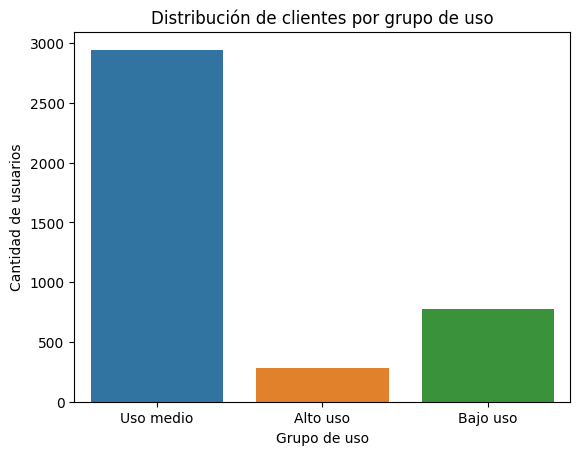

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

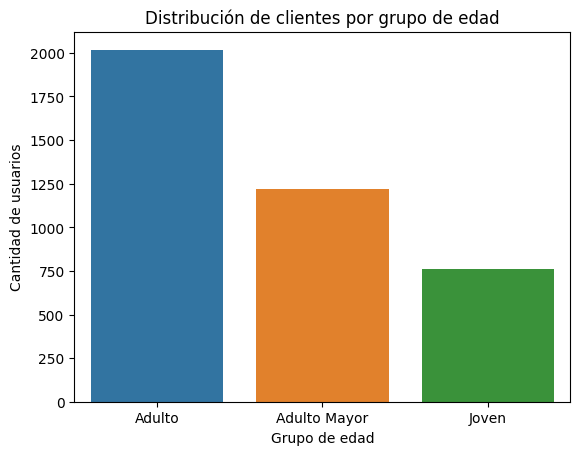

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [46]:
#Segmentación por nivel de uso
print(user_profile['grupo_uso'].value_counts())
print(user_profile['grupo_uso'].value_counts(normalize=True) * 100)
print()
#Segmentación por edad
print(user_profile['grupo_edad'].value_counts())
print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64
Uso medio    73.575
Bajo uso     19.450
Alto uso      6.975
Name: grupo_uso, dtype: float64

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


In [48]:
# Distribución de grupo_uso por plan (en % dentro de cada plan)
pd.crosstab(user_profile['grupo_uso'], user_profile['plan'], normalize='columns') * 100

plan,Basico,Premium
grupo_uso,,
Alto uso,7.167630,6.619217
Bajo uso,19.730250,18.932384
Uso medio,73.102119,74.448399


In [47]:
# Distribución de grupo_edad por plan (en % dentro de cada plan)
pd.crosstab(user_profile['grupo_edad'], user_profile['plan'], normalize='columns') * 100

plan,Basico,Premium
grupo_edad,,
Adulto,51.059730,49.323843
Adulto Mayor,30.211946,31.174377
Joven,18.728324,19.501779



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- `age`(dataset: users): contenía el valor sentinel -999 (edad inválida), fue reemplazado por la mediana.
- `city` (dataset:users): contenía 469 valores "?" que correspondian al 11.7%, estos fueron tratados como nulos.
- `reg_date` (dataset: users): contenía 40 registros con año 2026, que estaba fuera del rango de análisis del dataset usage, fueron marcados como nulos.
- `duration` y `length` (dataset: usage): contenían 55.2% y 44.7% de nulos respectivamente, se confirmaron como Missing at Random segun la variable `type`. Se dejaron como nulos
- Usando el método IQR se detectaron outliers superiores en: `cant_mensajes` (límite superior de 11.5, máximo observado de 17), `cant_llamadas` (límite superior de 10.5, máximo observado de 15) y `cant_minutos_llamada` (límite superior de 61.86, máximo observado de 155.69). Se decidió mantener estos outliers porque representan valores de uso posibles, no errores de captura. Para este negocio, implican que existe un grupo de clientes con consumo notablemente superior al promedio.

🔍 **Segmentos por Edad**
- Joven (usuarios menores a 30 años): 19% de los usuarios, lo que corresponde a 760 clientes
- Adulto (usuarios entre 30 y 59 años): 50.45% de los usuarios, lo que corresponde a 2018 clientes.
- Adulto Mayor (usuarios de más de 60 años): 30.55% de los usuarios, lo que corresponde a 1222 clientes.

📊 **Segmentos por Nivel de Uso**
- Bajo uso: 19.45% de los usuarios, lo que corresponde a 778 clientes.
- Uso medio: 73.58% de los usuarios, lo que corresponde a 2943 clientes.
- Alto uso: 6.98% de los usuarios, lo que corresponde a 279 clientes.

➡️ Esto sugiere que la base de clientes de ConnectaTel está compuesta mayoritariamente por  adultos (30-59 años) con un nivel de uso medio, lo que representa el perfil típico del cliente de la empresa. Además, al cruzar estos segmentos contra el tipo de plan, se confirma que tanto la edad como el nivel de uso están distribuidos de forma casi idéntica entre Básico y Premium

💡 **Recomendaciones**
-  Crear una oferta intermedia dirigida al segmento "Uso medio" (73.6% del total), ya que actualmente solo existen 2 planes (Básico/Premium) y este grupo mayoritario probablemente no está óptimamente atendido por ninguno de los dos extremos.
- Diseñar campañas de retención o mejora para clientes en plan Básico con "Alto uso" o con minutos de llamada por encima del límite superior IQR (61.86 min).
- Considerar planes adaptados para el segmento Adulto Mayor (30.55% del total), dado su proporción dentro de los grupos de edad.
- Estandarizar la captura de datos (`city`, `age`, `reg_date`) en el proceso de registro para reducir sentinels y errores de fecha a futuro.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`